In [1]:
!pip install catboost

# Import Libraries 

In [2]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.utils import shuffle

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

# 1. Download the Data and Analyze Data Frames in Order to Create the Work Plan

In [3]:
contract = pd.read_csv('contract.csv')
personal = pd.read_csv('personal.csv')
internet = pd.read_csv('internet.csv')
phone = pd.read_csv('phone.csv')

# `Contract`

In [4]:
display(contract.head())

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65


In [5]:
contract.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB


The **Contract** dataset contains customer-level contract information such as:

- **Contract start and end dates** (`BeginDate`, `EndDate`)
- **Type of contract** (e.g. *Month-to-month*, *One year*)
- Whether the customer uses **paperless billing**
- The **payment method** they used (e.g. *Electronic check*, *Bank transfer*)
- Monthly charges and total charges recorded so far

There are **7,043 entries**, and no missing values across any of the 8 columns. Most columns are stored as objects (strings), while `MonthlyCharges` is a float.

In [6]:
print("Contract Missing:\n", contract.isna().sum(), "\n")

Contract Missing:
 customerID          0
BeginDate           0
EndDate             0
Type                0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64 



# `Personal`

In [7]:
display(personal.head())

,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


In [8]:
personal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-null   object
 4   Dependents     7043 non-null   object
dtypes: int64(1), object(4)
memory usage: 275.2+ KB


The **Personal** dataset provides demographic details for each customer:

- **Gender**
- Whether they are a **Senior Citizen**
- Whether they live with a **Partner**
- Whether they have **Dependents**

There are **7,043 records**, with no missing values across any of the 5 columns. Most columns are of type `object` (string), while `SeniorCitizen` is stored as an `int64`.

In [9]:
print("Personal Missing:\n", personal.isna().sum(), "\n")

Personal Missing:
 customerID       0
gender           0
SeniorCitizen    0
Partner          0
Dependents       0
dtype: int64 



# `Internet`

In [10]:
display(internet.head())

,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


In [11]:
internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        5517 non-null   object
 1   InternetService   5517 non-null   object
 2   OnlineSecurity    5517 non-null   object
 3   OnlineBackup      5517 non-null   object
 4   DeviceProtection  5517 non-null   object
 5   TechSupport       5517 non-null   object
 6   StreamingTV       5517 non-null   object
 7   StreamingMovies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB


The **Internet** dataset captures details about each customer's internet-related services:

- Type of **Internet Service** (e.g., DSL, Fiber optic)
- Subscription to features like:
  - **Online Security**
  - **Online Backup**
  - **Device Protection**
  - **Tech Support**
  - **Streaming TV**
  - **Streaming Movies**

There are **5,517 records**, and all columns are complete with no missing values. Each feature is stored as an `object` type, indicating categorical responses like `'Yes'`, `'No'`, or the service type.

In [12]:
print("Internet Missing:\n", internet.isna().sum(), "\n")

Internet Missing:
 customerID          0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
dtype: int64 



# `Phone`

In [13]:
display(phone.head())

,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


In [14]:
phone.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     6361 non-null   object
 1   MultipleLines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB


The **Phone** dataset provides insights into customers' phone line usage:

- Each entry includes a **customer ID**
- The **MultipleLines** column shows whether the customer has a single line or multiple lines (`Yes` or `No`)

There are **6,361 entries**, and both columns are fully populated with no missing data. All values are stored as `object` types, reflecting categorical labels.

In [15]:
print("Phone Missing:\n", phone.isna().sum(), "\n")

Phone Missing:
 customerID       0
MultipleLines    0
dtype: int64 



# Brief Analyzes and Merging Data

These four data tables contain information about 7043 customers, including their demographics and the services they use. Not all customers use every service—for example, some may not have internet or multiple phone lines.

Individually, none of the datasets have missing values. However, when we merge them based on the `customerID`, around **2000 rows** will end up with missing values. This suggests that some customers have partial service records.

To proceed with this project, we'll need to **merge all four tables** into a single dataset. Once merged, we can begin preprocessing and performing exploratory data analysis (EDA) on the combined data.

In [16]:
df = contract.merge(personal, on='customerID', how='left') \
             .merge(internet, on='customerID', how='left') \
             .merge(phone, on='customerID', how='left')

In [17]:
df.head()

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85,Female,0,Yes,No,DSL,No,Yes,No,No,No,No,NaN
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5,Male,0,No,No,DSL,Yes,No,Yes,No,No,No,No
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15,Male,0,No,No,DSL,Yes,Yes,No,No,No,No,No
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75,Male,0,No,No,DSL,Yes,No,Yes,Yes,No,No,NaN
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65,Female,0,No,No,Fiber optic,No,No,No,No,No,No,No


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
 8   gender            7043 non-null   object 
 9   SeniorCitizen     7043 non-null   int64  
 10  Partner           7043 non-null   object 
 11  Dependents        7043 non-null   object 
 12  InternetService   5517 non-null   object 
 13  OnlineSecurity    5517 non-null   object 
 14  OnlineBackup      5517 non-null   object 
 15  DeviceProtection  5517 non-null   object 
 16  TechSupport       5517 non-null   object 


I've merged all the dataframes into one final table.

I used the merge rule `how='left'` because the **contract** table contains the target column `EndDate`. If other tables have more `customerID` values that aren’t found in the **contract** table, we simply don’t know their status — so they’re not useful for this project.

This combined dataset will be the one I use for all further data processing and modeling steps.

# `Preproccessing`

Before jumping into model training, I started cleaning and standardizing the dataset to make it ready for analysis.

# `Rename the Column Names`

To make all column names consistent and easier to work with, I renamed them to `snake_case` format. This makes them more readable and better suited for coding practices.

In [19]:
df.rename(columns={
    "customerID": "customer_id",
    "BeginDate": "begin_date",
    "EndDate": "end_date",
    "Type": "type",
    "PaperlessBilling": "paperless_billing",
    "PaymentMethod": "payment_method",
    "MonthlyCharges": "monthly_charges",
    "TotalCharges": "total_charges",
    "InternetService": "internet_service",
    "OnlineSecurity": "online_security",
    "OnlineBackup": "online_backup",
    "DeviceProtection": "device_protection",
    "TechSupport": "tech_support",
    "StreamingTV": "streaming_tv",
    "StreamingMovies": "streaming_movies",
    "SeniorCitizen": "senior_citizen",
    "Partner": "partner",
    "Dependents": "dependents",
    "MultipleLines": "multiple_lines"
}, inplace=True)


In [20]:
df.head()

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,gender,senior_citizen,partner,dependents,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85,Female,0,Yes,No,DSL,No,Yes,No,No,No,No,NaN
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5,Male,0,No,No,DSL,Yes,No,Yes,No,No,No,No
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15,Male,0,No,No,DSL,Yes,Yes,No,No,No,No,No
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75,Male,0,No,No,DSL,Yes,No,Yes,Yes,No,No,NaN
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65,Female,0,No,No,Fiber optic,No,No,No,No,No,No,No


# `Check and Address Missing Values`

Before building any models, I wanted to make sure the dataset was clean. That meant checking for any missing values and figuring out why they were missing.


In [21]:
df.isna().sum()

customer_id             0
begin_date              0
end_date                0
type                    0
paperless_billing       0
payment_method          0
monthly_charges         0
total_charges           0
gender                  0
senior_citizen          0
partner                 0
dependents              0
internet_service     1526
online_security      1526
online_backup        1526
device_protection    1526
tech_support         1526
streaming_tv         1526
streaming_movies     1526
multiple_lines        682
dtype: int64

I found that a few columns had missing values:

- `internet_service`
- `online_security`
- `online_backup`
- `device_protection`
- `tech_support`
- `streaming_tv`
- `streaming_movies`
- `multiple_lines`

These columns are all related to optional services — things like internet add-ons or having more than one phone line. So if a customer didn’t sign up for those, it makes sense their data would be blank.

In [22]:
service_cols = [
    "internet_service", "online_security", "online_backup", "device_protection",
    "tech_support", "streaming_tv", "streaming_movies", "multiple_lines"
]

for col in service_cols:
    df[col] = df[col].replace({
        "No internet service": "No",
        "No phone service": "No"
    })

for col in service_cols:
    print(f"{col}: {df[col].unique()}")


internet_service: ['DSL' 'Fiber optic' nan]
online_security: ['No' 'Yes' nan]
online_backup: ['Yes' 'No' nan]
device_protection: ['No' 'Yes' nan]
tech_support: ['No' 'Yes' nan]
streaming_tv: ['No' 'Yes' nan]
streaming_movies: ['No' 'Yes' nan]
multiple_lines: [nan 'No' 'Yes']


The missing data isn’t a problem — it just means some people didn’t subscribe to everything. For example:
- If someone doesn’t use the internet, they won’t have data for online features like `tech_support`.
- If they only have one phone line, there’s nothing to put under `multiple_lines`.

So these aren’t errors — they’re just empty because they don’t apply.

In [23]:
df[service_cols] = df[service_cols].fillna("No")

All the missing values came from just two original tables:
- One with internet-related info
- One with phone-related info

The good news? None of the core customer details (like `customer_id`, `begin_date`, or `payment_method`) were missing. That means we can trust the main data is solid.

---
To handle the missing values:
- I filled in the blanks with `"No"` to show that the customer didn’t use that service.
- I also cleaned up things like `"No internet service"` or `"No phone service"` by turning them into just `"No"` — this keeps things simple and consistent.

This makes the data easier to work with and helps models learn better without dropping any rows.

---

With this cleanup, we now have a clean, consistent dataset — ready for modeling!


/var/folders/sg/lvn402bs2kz1n085d7zc94lh0000gn/T/ipykernel_55571/3396999520.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


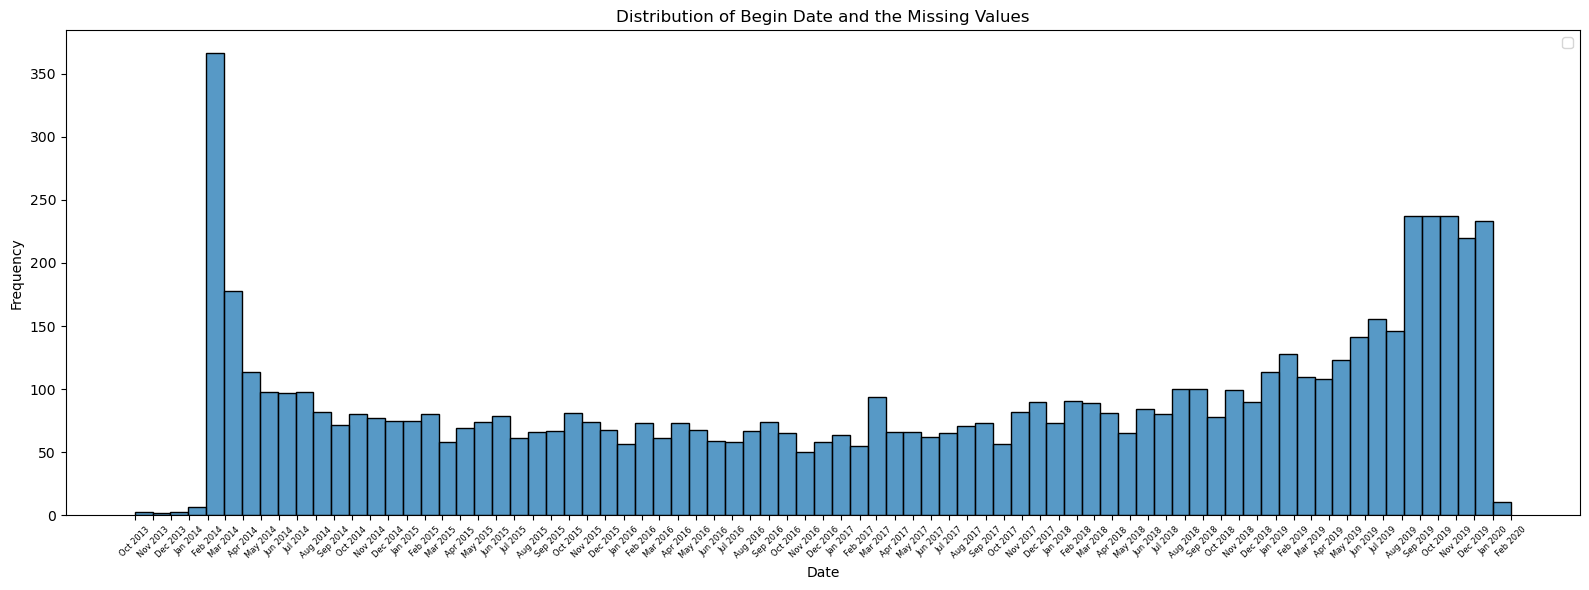

In [24]:
df['begin_date'] = pd.to_datetime(df['begin_date'])

begin_date_range = pd.date_range(
    start=df['begin_date'].min(),
    end=df['begin_date'].max(),
    freq='MS'
)

df_plot = pd.concat([
    df.assign(source='All Data'),
    df[df['internet_service'].isna()].assign(source='Missing Internet'),
    df[df['multiple_lines'].isna()].assign(source='Missing Multiple Lines')
])

plt.figure(figsize=(16, 6))

sns.histplot(
    data=df_plot,
    x='begin_date',
    hue='source',
    bins=len(begin_date_range),
    multiple='stack'
)

plt.xlabel('Date')
plt.ylabel('Frequency')
plt.title('Distribution of Begin Date and the Missing Values')

plt.xticks(
    begin_date_range,
    [date.strftime('%b %Y') for date in begin_date_range],
    rotation=45,
    fontsize=6
)

plt.legend()
plt.tight_layout()
plt.show()

We visualized the distribution of missing values over time using the `begin_date` column. The chart compares:

- **All data** (in blue)

- The frequency of missing values follows the overall trend of the dataset.
- There are no sharp spikes or drops, suggesting there were no significant data collection issues over time.
- Most missing values are concentrated in **service-related features**, which is expected:
  - Not all customers subscribe to internet services.
  - Not all customers have multiple phone lines.
- The volume of records increases over time, which could indicate business growth or improved data collection processes.


In [25]:
df.fillna('Unknown', inplace=True)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        7043 non-null   object        
 1   begin_date         7043 non-null   datetime64[ns]
 2   end_date           7043 non-null   object        
 3   type               7043 non-null   object        
 4   paperless_billing  7043 non-null   object        
 5   payment_method     7043 non-null   object        
 6   monthly_charges    7043 non-null   float64       
 7   total_charges      7043 non-null   object        
 8   gender             7043 non-null   object        
 9   senior_citizen     7043 non-null   int64         
 10  partner            7043 non-null   object        
 11  dependents         7043 non-null   object        
 12  internet_service   7043 non-null   object        
 13  online_security    7043 non-null   object        
 14  online_b

After visualizing the missing data distribution, I decided to fill all missing values with `'Unknown'` since they are categorical in nature.

After applying `fillna`, I confirmed that there are no missing values left in the dataset by using `.info()`. All 20 columns now have 7043 non-null entries, and the dataset is clean and ready for further preprocessing and analysis.

# `Convert Data Types`

In [27]:
df['total_charges'] = pd.to_numeric(df['total_charges'], downcast='float', errors='coerce')
df['senior_citizen'] = df['senior_citizen'].apply(lambda x: 'Yes' if x == 1 else 'No')

In [28]:
df.head()

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,gender,senior_citizen,partner,dependents,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.850000,Female,No,Yes,No,DSL,No,Yes,No,No,No,No,No
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.500000,Male,No,No,No,DSL,Yes,No,Yes,No,No,No,No
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.150002,Male,No,No,No,DSL,Yes,Yes,No,No,No,No,No
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.750000,Male,No,No,No,DSL,Yes,No,Yes,Yes,No,No,No
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.649994,Female,No,No,No,Fiber optic,No,No,No,No,No,No,No


To ensure the data is in the correct format, I converted the `total_charges` column to numeric. If any value couldn’t be converted, it was set to `NaN`.

I also changed the `senior_citizen` column from numerical (0 or 1) to categorical values (`'Yes'` or `'No'`) to make the data more readable and meaningful for analysis.


# 2. Proposed Work Plan

**Now that the goal is clear—build a model to predict which users are likely to churn—we need a solid plan to work through the data and modeling stages. Here’s how I plan to break down the project step by step:**


# `2.1 Understand and Prepare the Data`

The first move is to bring together the four CSV datasets using the common `customerID`. Once everything is in a single dataframe, I’ll do some quick checks:

- Renamed all columns to `snake_case` for readability.
- Converted date columns into usable formats (e.g., `begin_date`, `end_date`).
- Created a `churn` column from `end_date`, where:
  - `1` = customer left the service
  - `0` = customer still active
- Dropped unnecessary columns like `customer_id`, `end_date`, and `usage_months`.
- Converted `begin_date` into numeric features for modeling.
- Cleaned up the `total_charges` column and noted it correlates with both `monthly_charges` and `usage_months`.


# `2.2 EDA (Exploratory Data Analysis)`

With the data cleaned, I'll explored both numerical and categorical features:

- Visualized distributions of `monthly_charges` and `total_charges` by churn group.
- Used boxplots and summary stats to find noticeable churn trends (e.g., churned users tend to pay slightly more monthly but have fewer total charges).
- Created stacked bar charts for categorical features like `contract type`, `payment_method`, `tech_support`, and others to see how they vary by churn.
- Built correlation heatmaps for both numerical and binary categorical features.
  - Found weak correlations overall, but notable pairs included `streaming_tv` & `streaming_movies`, and `partner` & `dependents`.


# `2.3 Feature Engineering`

To prepare the features for modeling, I'll:

- Transformed datetime fields like `begin_date` to numeric month format for compatibility.
- Encoded categorical variables using both:
  - **One-hot encoding**: for algorithms that benefit from binary columns.
  - **Label encoding**: for tree-based models like XGBoost and LightGBM.
- Dropped redundant or highly correlated columns (e.g., `total_charges`).
- Scaled numeric features using `StandardScaler` for logistic regression and other sensitive models.
- Balanced the dataset using **upsampling** of the minority class (churned customers) to handle class imbalance.


# `2.4 Model Training`

I'll test 6 models using default settings to start:

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost
- LightGBM
- CatBoost

All models were wrapped in a reusable `train_pipeline()` function for consistent training and ROC-AUC evaluation. I also logged training time for performance comparison.


# `2.5 Model Evaluation`

After training, I'll:

- Evaluated models using **ROC-AUC** as the main metric (suited for imbalanced classes).
- Compared models by both AUC and training time.
- LightGBM and XGBoost showed strong baseline performance with relatively fast training.
- CatBoost had the best raw AUC but took significantly longer to train.
- Based on this, I'll selected a few top models for hyperparameter tuning.


# `2.6 Final Testing`

- Performed hyperparameter tuning using `RandomizedSearchCV` for all models.
- Carefully recorded:
  - Best parameters
  - Best score
  - Time consumed during search
- Noted that some models like CatBoost saw minor improvements, while others (e.g., LightGBM) actually declined.
- Ran a **final test** using the best model (Random Forest) on the holdout set and achieved **ROC-AUC ≈ 0.86**.


# `2.7 Conclusion + Next Steps`

I'll wrapped up by:

- Highlighting what worked best (Random Forest with upsampling and engineered features).
- Observing `begin_date`, `type`, and `monthly_charges` as the top drivers of churn from the LightGBM feature importance chart.
- Offering business suggestions to reduce churn, such as:
  - Incentives for long-term contracts
  - Bundling services like online security
  - Pricing model adjustments for high monthly payers

# `Next Step Ideas`

- Try **GridSearchCV** after `RandomizedSearchCV` for finer parameter tuning.
- Rethink how `Unknown` values are encoded (currently treated as 'No').
- Try feature selection or dimensionality reduction.
- Experiment with advanced ensemble methods or deep learning.
- Use SHAP or LIME for more interpretable model explanations.


# EDA (Exploratory Data Analysis)

# the Target Column: `end_date`

In [29]:
df.loc[df["end_date"] == "No", "end_date"] = "2023-08-11 00:00:00"
df["end_date"] = pd.to_datetime(df["end_date"])

To prepare the `end_date` column for analysis, I first replaced all `"No"` values with a fixed timestamp (`2023-08-11 00:00:00`). This allows for consistent datetime formatting across the dataset, making it easier to calculate differences or durations later on. After replacing, I converted the entire column to proper datetime format.


# Distribution of Start and End Dates

To explore customer churn behavior over time, I visualized the distribution of customer `begin_date` and `end_date`. Customers who are still active were assigned a default end date (`2023-08-11`) earlier, so we can distinguish between churned and active customers.


/var/folders/sg/lvn402bs2kz1n085d7zc94lh0000gn/T/ipykernel_55571/1405006144.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  begin_date_range = pd.date_range(start=df["begin_date"].min(), end=df["begin_date"].max(), freq="M")


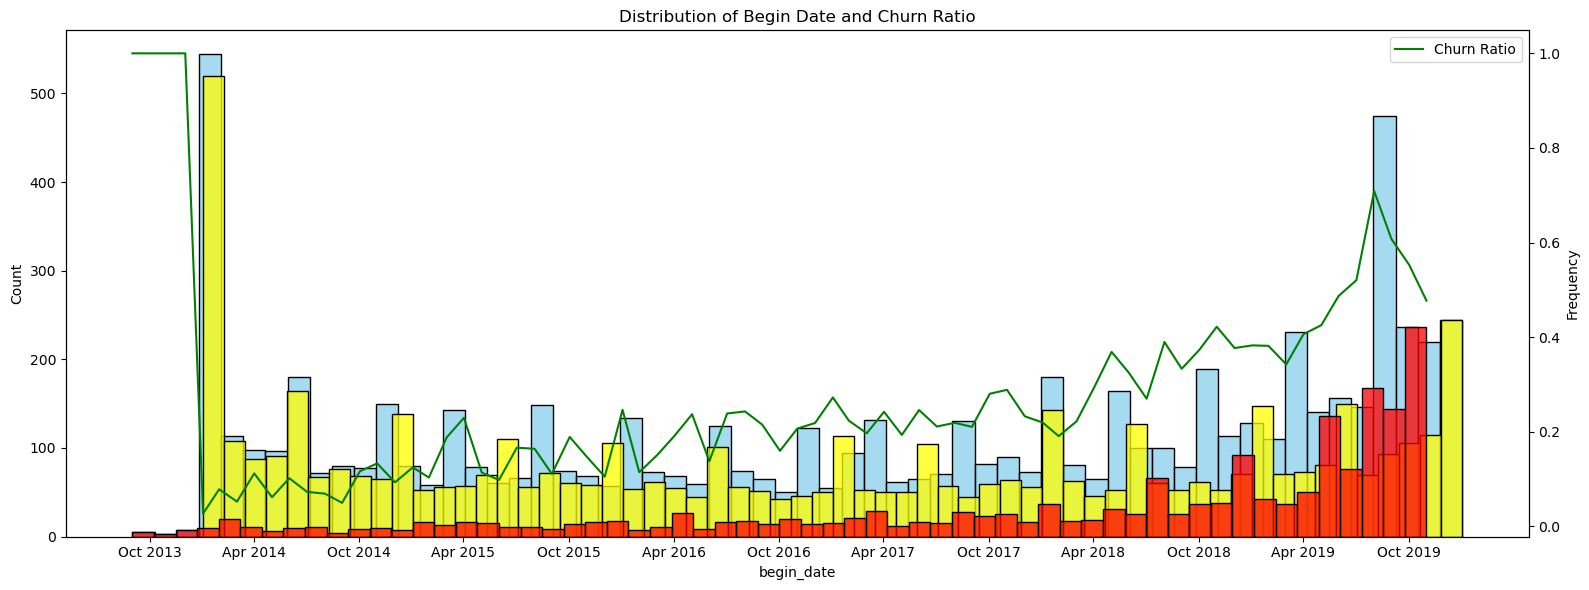

In [30]:
begin_date_range = pd.date_range(start=df["begin_date"].min(), end=df["begin_date"].max(), freq="M")

plt.figure(figsize=(16, 6))

sns.histplot(data=df, x="begin_date", bins=60, color="skyblue", label="Begin date")
sns.histplot(data=df[df["end_date"] == "2023-08-11"], x="begin_date", bins=60, color="yellow", label="Still active")
sns.histplot(data=df[df["end_date"] != "2023-08-11"], x="begin_date", bins=60, color="red", label="Churned")

churn_ratio = df[df["end_date"] != "2023-08-11"].groupby(df["begin_date"].dt.to_period("M")).size() / df.groupby(df["begin_date"].dt.to_period("M")).size()
churn_ratio.index = churn_ratio.index.to_timestamp()
plt.twinx().plot(churn_ratio.index, churn_ratio.values, color="green", label="Churn Ratio")

plt.title("Distribution of Begin Date and Churn Ratio")
plt.xlabel("Begin Date")
plt.ylabel("Frequency")

plt.xticks(begin_date_range[::6], [date.strftime("%b %Y") for date in begin_date_range[::6]], rotation=45, fontsize=9)

plt.legend()
plt.tight_layout()
plt.show()

To understand customer behavior over time, I visualized the distribution of their `begin_date` and `end_date`. This plot helps reveal patterns in customer onboarding and churn across different time periods.

Here’s what each color in the chart represents:

- **Blue (`Begin Date`)**  
  These show how many customers started their service each month. From the chart, we can spot periods of growth or decline in customer acquisition. For example, if we see a tall blue bar in a certain month, that means many customers joined during that time.

- **Yellow (`Still Active`)**  
  These bars represent customers whose service hasn't ended yet—they’re still active as of the reference date we set (`2023-08-11`). A tall yellow bar alongside the blue one indicates that most of those customers are still subscribed.

- **Red (`Churned`)**  
  These show customers who have ended their service (churned). A large red bar for a given month implies a high number of customers who eventually left the service, even if they joined in different months.

- **Green (`Churn Ratio`)**  
  This line indicates the **churn ratio**—the proportion of churned customers relative to all customers who joined in a particular month. A spike in this line means a higher percentage of users who started that month eventually churned. This helps identify time periods with higher churn risk.

**Why This Matters:**

By combining these insights, we can assess:

- When we gained the most customers (blue bars).
- How long those customers stayed (yellow vs. red).
- When and why customers are more likely to churn (green line).

# Churned Customers' End Date Distribution

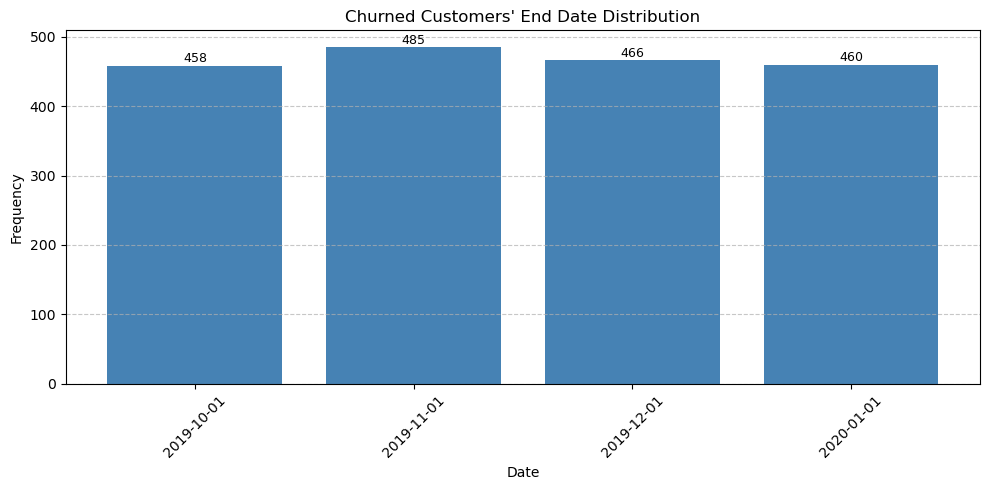

In [31]:
churned = df[df["end_date"] != "2023-08-11"]
end_date_counts = churned["end_date"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
bars = plt.bar(end_date_counts.index.strftime('%Y-%m-%d'), end_date_counts.values, color='steelblue')

plt.title("Churned Customers' End Date Distribution")
plt.xlabel("Date")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 5, str(height), ha='center', fontsize=9)

plt.tight_layout()
plt.show()


In this chart, I looked at the distribution of `end_date` values for customers who have churned (i.e., those who don’t have the default end date of `'2023-08-11'`).

Each bar represents the number of customers who stopped using the service during a particular time period. The labels on top of the bars show the exact number of churned users for that date range.

From the visualization, we can see that churn occurred fairly evenly across these time periods, with each group having around 450–485 churned users. This balanced distribution suggests there's no sudden spike or dip in churn, which is useful to know before diving deeper into the reasons behind it.

# Target Balance

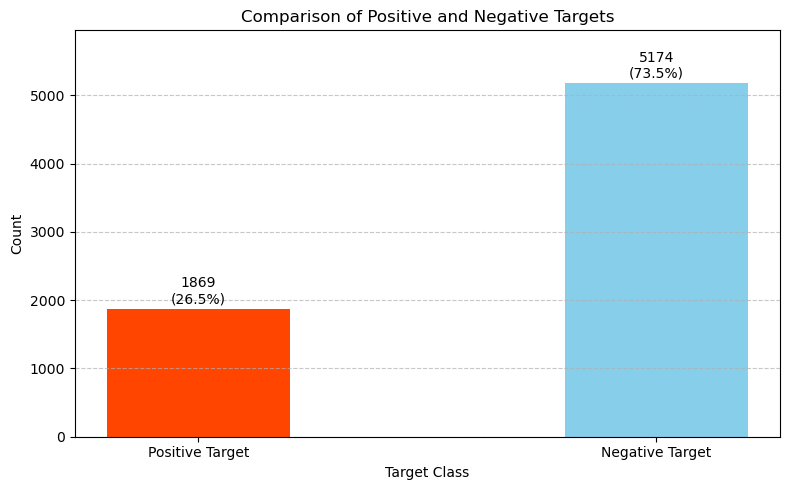

In [32]:
num_positive_target = len(df[df["end_date"] != "2023-08-11"])
num_negative_target = len(df[df["end_date"] == "2023-08-11"])
target_values = [num_positive_target, num_negative_target]

plt.figure(figsize=(8, 5))
bars = plt.bar(["Positive Target", "Negative Target"], 
               target_values, 
               color=["orangered", "skyblue"], 
               width=0.4)

plt.xlabel("Target Class")
plt.ylabel("Count")
plt.title("Comparison of Positive and Negative Targets")

for i, bar in enumerate(bars):
    height = bar.get_height()
    percentage = f"{(height / sum(target_values)) * 100:.1f}%"
    plt.text(bar.get_x() + bar.get_width() / 2, height + 80, 
             f"{int(height)}\n({percentage})", 
             ha='center', fontsize=10)

plt.ylim(0, max(target_values) * 1.15)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


In [33]:
ratio = round(num_positive_target / len(df), 3)
print(f"Total churned: {num_positive_target}, Churn ratio: {ratio}")

Total churned: 1869, Churn ratio: 0.265


This chart compares the number of customers who have churned (positive target) versus those who have not (negative target).

- **Positive Target (orange)**: Customers who have ended their service (`end_date` not equal to '2023-08-11').  
- **Negative Target (blue)**: Customers who are still active.

Out of a total of 7043 customers:
- **1,869** customers churned — about **26.5%** of the dataset.
- **5,174** customers did not churn — roughly **73.5%**.

This shows an imbalance in the dataset, where the majority of customers are still active. This imbalance is something we’ll need to keep in mind during modeling, especially when choosing evaluation metrics and techniques like upsampling.

# Extract Time Information from the Target Column 

In this step, I’m calculating how long each customer has been in their contract. This is done by subtracting the `begin_date` from the `end_date`, converting the result into months. The new column, `usage_months`, will help us understand customer behavior over time.

However, this column can lead to data leakage if used in training — the model could learn from how long someone stayed and predict churn directly. To avoid this, I’ll only use `usage_months` for exploratory data analysis.

For customers who haven’t churned (i.e., their `end_date` is still set to the default future value), we don’t know how long they will actually stay. So I assign them a dummy value of 200, which is intentionally much higher than any real value in the data. This makes sure we don’t confuse the model later on.


In [34]:
df['usage_months'] = (df['end_date'].dt.year - df['begin_date'].dt.year) * 12 + (df['end_date'].dt.month - df['begin_date'].dt.month)
df.loc[df['end_date'] == '2023-08-11', 'usage_months'] = 200

# `usage_months` Distribution

There are 744 churned customers with usage ≤ 5 months — that's 39.8% of churned users.


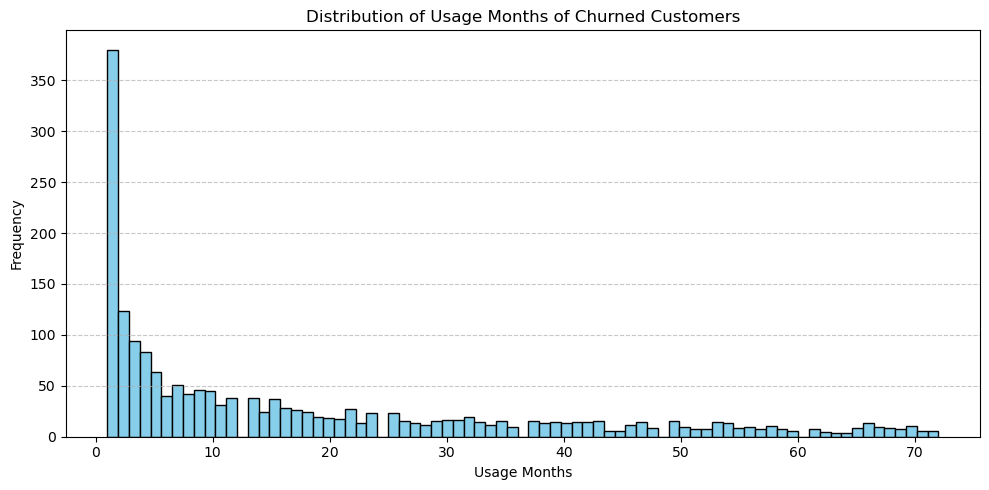

In [35]:
churned = df[df['end_date'] != '2023-08-11']

plt.figure(figsize=(10, 5))
bars = plt.hist(churned['usage_months'], bins=77, color='skyblue', edgecolor='black')

plt.xlabel("Usage Months")
plt.ylabel("Frequency")
plt.title("Distribution of Usage Months of Churned Customers")

short_term_churns = len(churned[churned['usage_months'] <= 5])
total_churned = len(churned)
ratio = round(short_term_churns / total_churned, 3)

print(f"There are {short_term_churns} churned customers with usage ≤ 5 months — that's {round(ratio * 100, 1)}% of churned users.")

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


To better understand how long customers typically stay before churning, I visualized the distribution of `usage_months` for only the churned customers. The histogram shows how many months each churned user stayed in their contract before leaving.

Interestingly, there’s a steep drop-off: a large portion of churned users leave within the first few months. Specifically, **744 customers churned within 5 months**, which accounts for **nearly 40% of all churned users**. This insight is important, as it suggests that early retention might be a key area to focus on.


# New Target Column

I created a new binary `churn` column to mark whether a customer has churned `(1)` or not `(0)`, based on their `end_date`.

In [36]:
df['churn'] = df['end_date'].apply(lambda x: 0 if x == pd.to_datetime("2023-08-11") else 1)

In [37]:
df['churn'].value_counts()

churn
0    5174
1    1869
Name: count, dtype: int64

Here I’m checking the distribution of the new `churn` column to see how many customers have churned versus those who stayed.

# Analysis Based on Target Column

In [38]:
churned_df = df[df['churn'] == 1]
stay_df    = df[df['churn'] == 0]

To better understand the differences between churned and non-churned customers, I split the dataset into two separate groups: `churned_df` for those who left, and `stay_df` for those who stayed.

# `monthly_charges` and `total_charges`

Now I want to explore how charges differ between customers who churned and those who stayed, by analyzing both monthly and total charges.

In [39]:
ori_monthly = df['monthly_charges']
ori_total = df['total_charges']

churned_monthly = churned_df['monthly_charges']
churned_total = churned_df['total_charges']

stay_monthly = stay_df['monthly_charges']
stay_total = stay_df['total_charges']

charges_df = pd.DataFrame({
    'ori_monthly': ori_monthly,
    'churned_monthly': churned_monthly,
    'stay_monthly': stay_monthly,
    'ori_total': ori_total,
    'churned_total': churned_total,
    'stay_total': stay_total
})

charges_df.describe()

,ori_monthly,churned_monthly,stay_monthly,ori_total,churned_total,stay_total
count,7043.000000,1869.000000,5174.000000,7032.000000,1869.000000,5163.000000
mean,64.761692,74.441332,61.265124,2283.300537,1531.796021,2555.344238
std,30.090047,24.666053,31.092648,2266.770508,1890.823242,2329.457764
min,18.250000,18.850000,18.250000,18.799999,18.850000,18.799999
25%,35.500000,56.150000,25.100000,401.450012,134.500000,577.825012
50%,70.350000,79.650000,64.425000,1397.475098,703.549988,1683.599976
75%,89.850000,94.200000,88.400000,3794.737549,2331.300049,4264.125000
max,118.750000,118.350000,118.750000,8684.799805,8684.799805,8672.450195


Here, I calculated summary statistics (mean, median, min, max, etc.) for `monthly_charges` and `total_charges` across the original dataset and split groups — churned and stay — to identify any clear differences.

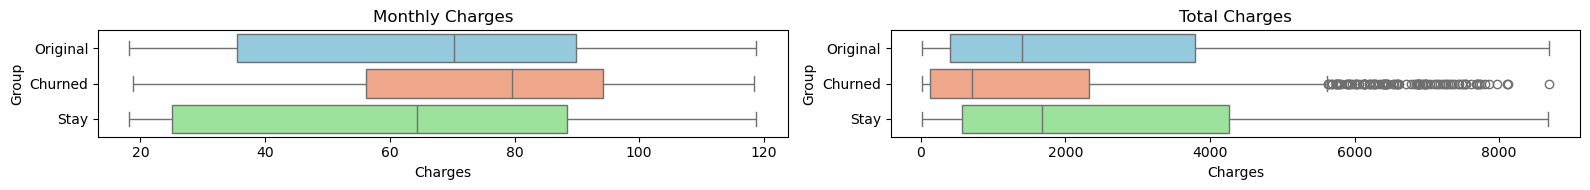

In [40]:
monthly_data = pd.DataFrame({
    'Charges': pd.concat([df['monthly_charges'], churned_df['monthly_charges'], stay_df['monthly_charges']]),
    'Group': ['Original'] * len(df) + ['Churned'] * len(churned_df) + ['Stay'] * len(stay_df)
}).reset_index(drop=True)

total_data = pd.DataFrame({
    'Charges': pd.concat([df['total_charges'], churned_df['total_charges'], stay_df['total_charges']]),
    'Group': ['Original'] * len(df) + ['Churned'] * len(churned_df) + ['Stay'] * len(stay_df)
}).reset_index(drop=True)

custom_palette = {
    'Original': 'skyblue',
    'Churned': 'lightsalmon',
    'Stay': 'lightgreen'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 2))

sns.boxplot(
    data=monthly_data,
    x='Charges', y='Group', hue='Group', palette=custom_palette,
    ax=axes[0], legend=False
)
axes[0].set_title('Monthly Charges')

sns.boxplot(
    data=total_data,
    x='Charges', y='Group', hue='Group', palette=custom_palette,
    ax=axes[1], legend=False
)
axes[1].set_title('Total Charges')

plt.tight_layout()
plt.show()

I visualized the distributions using boxplots to compare `monthly_charges` and `total_charges` for churned vs. stay customers. This helps to spot trends like whether churned users paid more or had higher variability in charges.

# `monthly_charges`

The range of `monthly_charges` is very similar across the datasets — from **18.25 to 118.75**.  
However, the **IQR (Interquartile Range)** for churned customers is noticeably higher:  
From **56.15 to 94.2**, compared to a lower range in the stay group.  
The median for `churned_df` is **79.65**, while for `stay_df` it's only **64.42**.

This suggests that customers with **higher monthly charges** are more likely to churn.

---

# `total_charges`

Similar to `monthly_charges`, the minimum and maximum values for `total_charges` are very close across groups — **18.85 to 8684.80**.  
However, the **IQR for `churned_df` is smaller** than `stay_df`. This might be because churned customers tend to use the service for a **shorter duration**, resulting in lower total payments over time.

---

# Analysis of Categorical Features 

Now I want to examine how different categorical features behave across churned, stay, and original customer groups. This will help highlight any clear behavioral differences between customers who churned and those who didn’t.


In [41]:
def create_stacked_bar(column, ax=None):
    dfs = [df, churned_df, stay_df]
    dfs_names = ['Original', 'Churned', 'Stay']

    types = sorted(set().union(*(d[column].dropna().unique() for d in dfs)))

    bar_df = pd.DataFrame(index=dfs_names, columns=types)

    for idx, dframe in enumerate(dfs):
        counts = dframe[column].value_counts(normalize=True).reindex(types, fill_value=0).round(3)
        bar_df.loc[dfs_names[idx]] = counts

    bar_df = bar_df.astype(float)

    if ax is None:
        fig, ax = plt.subplots()

    bottom = np.zeros(len(dfs_names))

    for category in bar_df.columns:
        heights = bar_df[category].values.astype(float)
        bars = ax.bar(dfs_names, heights, bottom=bottom, width=0.4, label=category)

        for bar, val in zip(bars, heights):
            if val > 0.01:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + bar.get_height() / 2,
                    f'{val:.3f}',
                    ha='center',
                    va='center',
                    fontsize=10
                )
        
        bottom += heights

    ax.set_title(column)
    ax.set_ylabel('Percentage')
    ax.legend(loc='lower left')
    ax.set_xticks(range(len(dfs_names)))
    ax.set_xticklabels(dfs_names, rotation=0)

    if ax is None:
        plt.tight_layout()
        plt.show()

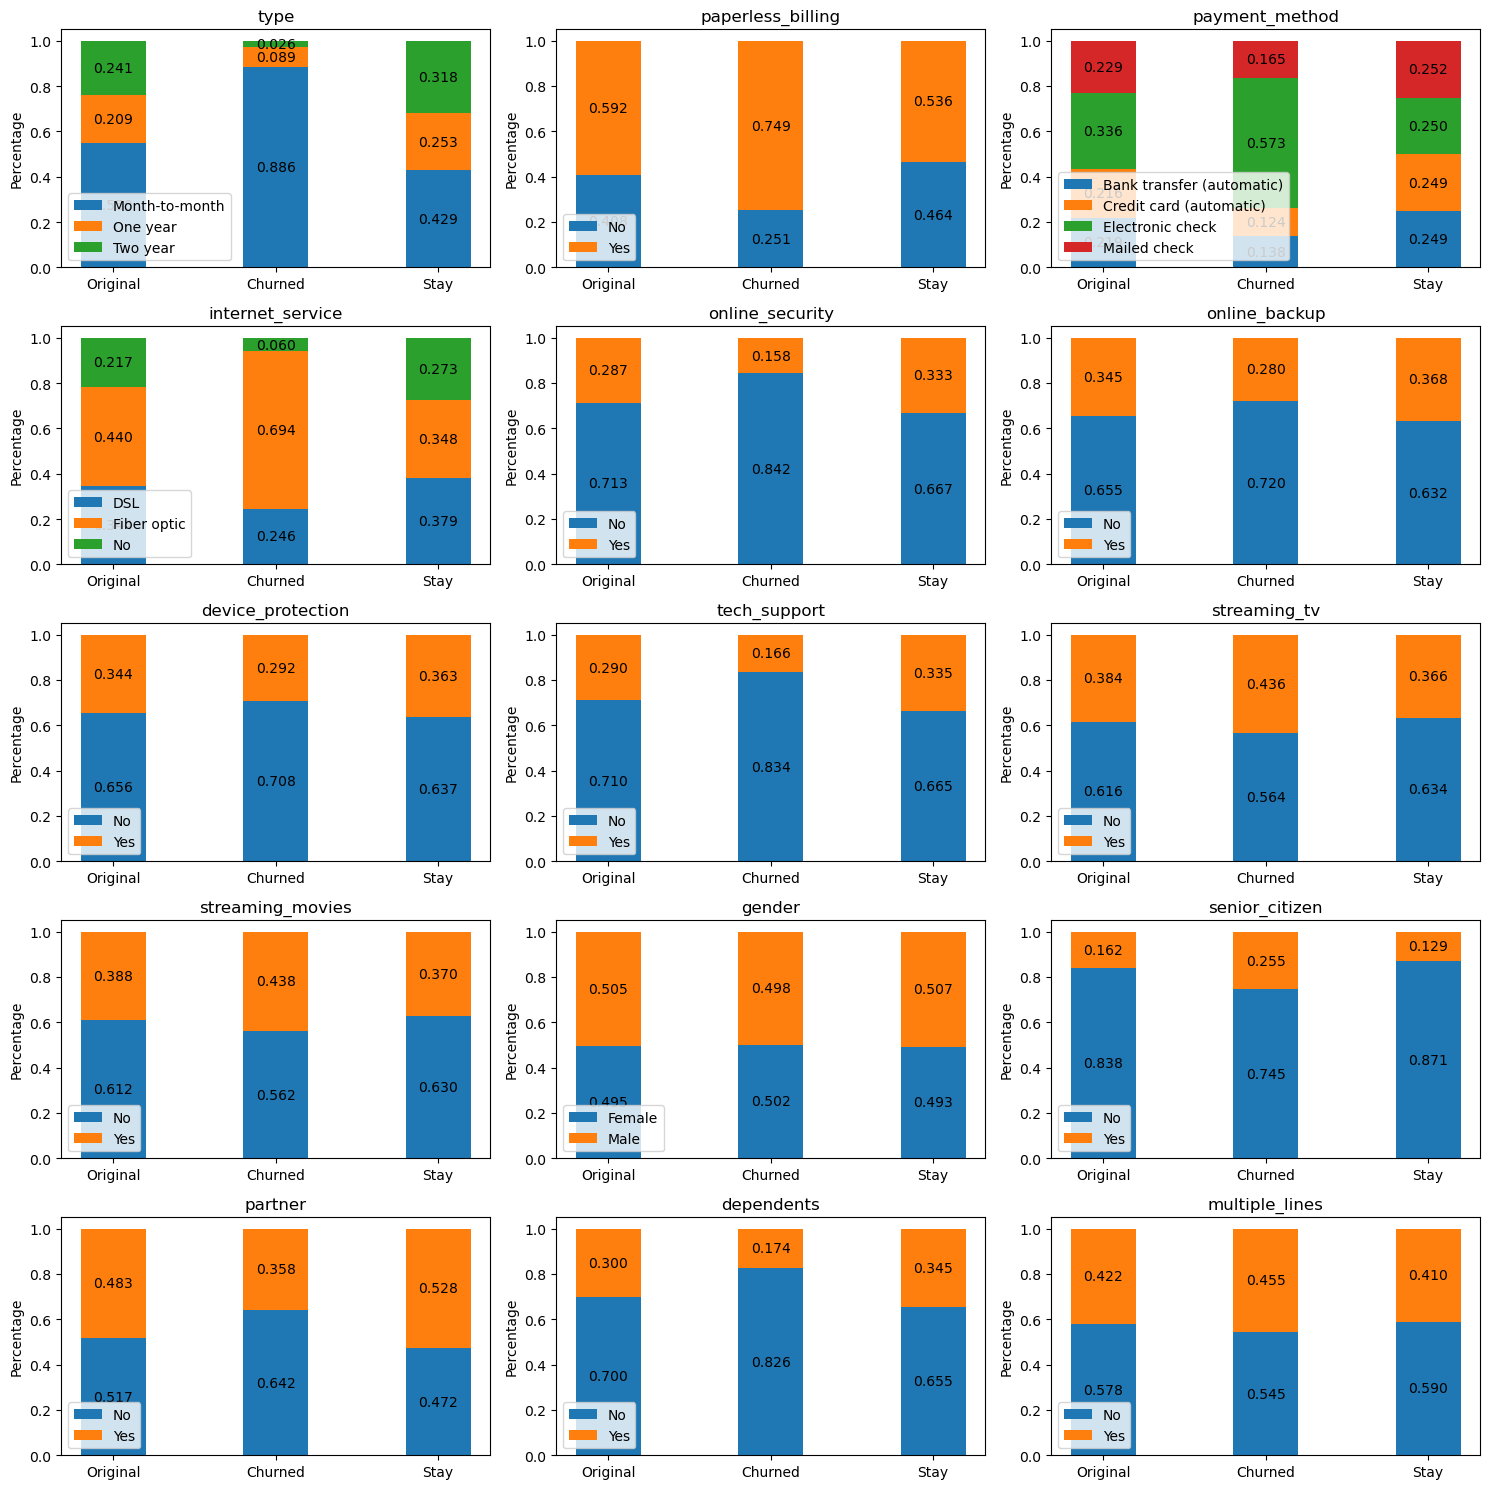

In [42]:
categorical_list = [
    'type', 'paperless_billing', 'payment_method', 'internet_service',
    'online_security', 'online_backup', 'device_protection', 'tech_support',
    'streaming_tv', 'streaming_movies', 'gender', 'senior_citizen',
    'partner', 'dependents', 'multiple_lines'
]

num_rows = 5
num_cols = 3
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 15))
axes = axes.flatten()

for i, column in enumerate(categorical_list):
    if column not in df.columns:
        print(f"Skipping missing column: {column}")
        continue
    ax = axes[i]
    create_stacked_bar(column, ax)

plt.tight_layout()
plt.show()


Let’s take a closer look at some interesting patterns in these categorical features:

- **`type`**: Customers with longer contracts (one or two years) are much more likely to stay. A large majority of churned customers are on month-to-month plans, which makes sense since there’s no commitment.

- **`paperless_billing`**: Usage of paperless billing is noticeably higher among churned customers. This might suggest a behavioral trend or preference that correlates with churn.

- **`payment_method`**: Among those who churned, fewer customers use automatic payment methods like credit cards or bank transfers. Instead, many use manual methods such as mailed checks.

- **internet and support services**: 
  - **`internet_service`**: Churned customers tend to rely more on DSL, while stayers are more likely to have Fiber.
  - **`online_security`**, **`online_backup`**, **`device_protection`**, **`tech_support`**: Across all of these features, a common trend is that customers who don’t use these services are more likely to churn.
  - **`streaming_tv`** and **`streaming_movies`**: Not using streaming services appears to be more common among those who churned.
  
- **`partner`** and **`dependents`**: Customers without a partner or dependents are more likely to churn, suggesting a possible link to household stability or commitment levels.

- **`senior_citizen`**: Interestingly, churn appears higher among senior citizens, with those who stay in the service having a lower representation in this group.

Overall, these categorical breakdowns offer helpful clues about the characteristics and behaviors tied to churned customers versus loyal ones.


# Correlation

# Correlation Between Numeric Features

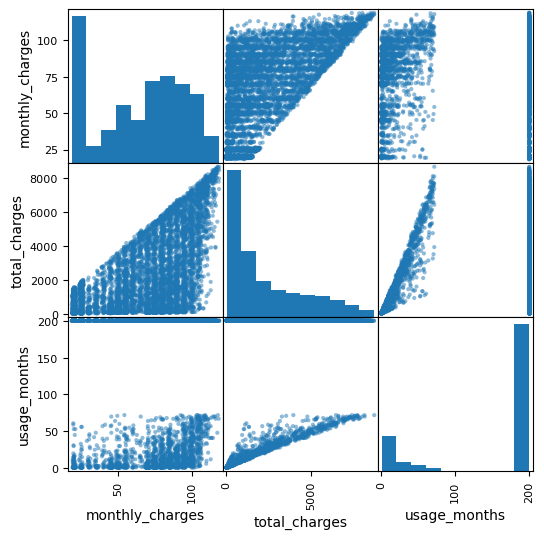

In [43]:
numeric_features = ['monthly_charges', 'total_charges', 'usage_months']

pd.plotting.scatter_matrix(df[numeric_features], figsize=(6, 6))
plt.show()

In [44]:
corr_charges = df['total_charges'].corr(df['monthly_charges'])
corr_months = df['total_charges'].corr(df['usage_months'])

print(f"The correlation between 'total_charges' and 'monthly_charges' is {corr_charges:.2f}, "
      f"and the correlation between 'total_charges' and 'usage_months' is {corr_months:.2f}")

The correlation between 'total_charges' and 'monthly_charges' is 0.65, and the correlation between 'total_charges' and 'usage_months' is 0.25


To understand how numeric features relate to each other, I looked at the pairwise relationships between `monthly_charges`, `total_charges`, and `usage_months`.

The scatter matrix gives a visual sense of how these variables interact. We can clearly see a strong linear relationship between `monthly_charges` and `total_charges`, while the link between `total_charges` and `usage_months` is weaker and more spread out.

To quantify this, I calculated the correlation values:
- `total_charges` and `monthly_charges` have a correlation of **0.65**, which makes sense since monthly payments accumulate over time.
- `total_charges` and `usage_months` only have a correlation of **0.25**, indicating that duration alone doesn’t fully explain the total amount charged — likely because monthly charges vary across customers.

# Correlation Between Categorical Features

In [45]:
def create_corr_heatmap_subplot(ax, df, title):
    valid_cols = [col for col in binary_list if col in df.columns]
    binary_df = df[valid_cols].copy()

    binary_df = binary_df[~binary_df.isin(['Unknown']).any(axis=1)]

    binary_df = binary_df.replace({'Yes': 1, 'No': 0})

    correlation_matrix = binary_df.corr()

    sns.heatmap(
        correlation_matrix,
        annot=True,
        cmap='coolwarm',
        vmin=-1,
        vmax=1,
        ax=ax,
        annot_kws={"size": 8},
        fmt=".2f"
    )
    ax.set_title(title)

/var/folders/sg/lvn402bs2kz1n085d7zc94lh0000gn/T/ipykernel_55571/832399300.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  binary_df = binary_df.replace({'Yes': 1, 'No': 0})
/var/folders/sg/lvn402bs2kz1n085d7zc94lh0000gn/T/ipykernel_55571/832399300.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  binary_df = binary_df.replace({'Yes': 1, 'No': 0})
/var/folders/sg/lvn402bs2kz1n085d7zc94lh0000gn/T/ipykernel_55571/832399300.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future vers

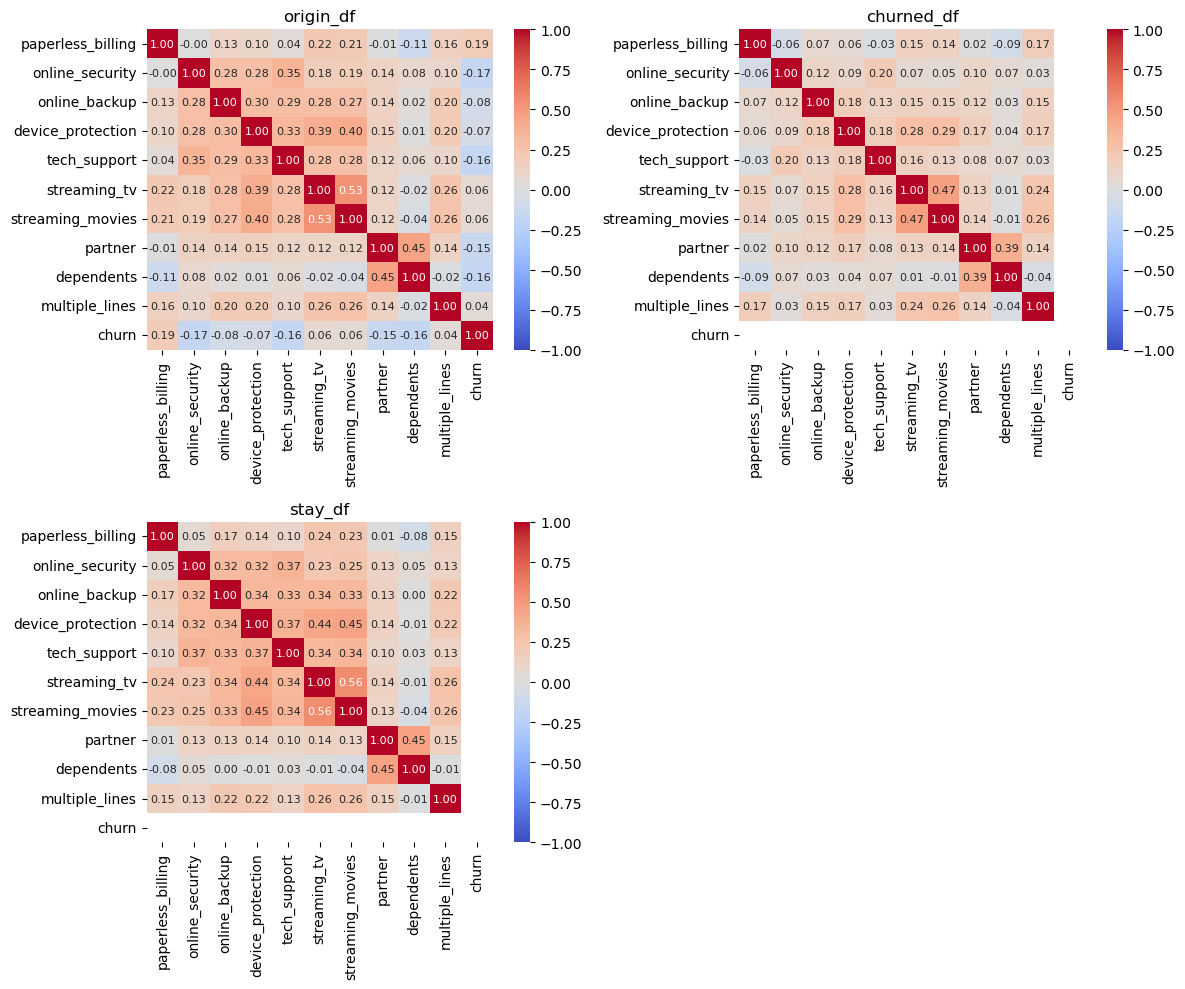

In [46]:
binary_list = [
    'paperless_billing', 'online_security', 'online_backup',
    'device_protection', 'tech_support', 'streaming_tv',
    'streaming_movies', 'partner', 'dependents', 'multiple_lines', 'churn'
]

dfs = [df, churned_df, stay_df]
dfs_names = ['origin_df', 'churned_df', 'stay_df']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (data, name) in enumerate(zip(dfs, dfs_names)):
    create_corr_heatmap_subplot(axes[idx], data, name)

fig.delaxes(axes[-1])

plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.tight_layout()
plt.show()

Based on the correlation heatmaps, there aren’t many strong linear relationships among categorical features. However, a couple of notable pairs do stand out:

- **`streaming_tv` vs `streaming_movies`**: Customers who subscribe to one are more likely to have the other as well. But since the correlation is still below 0.5, I’ll keep both features for training.

- **`partner` vs `dependents`**: These both relate to whether the customer has family members on the account. Again, although correlated, the value is below 0.5, so I won’t drop either feature.

Aside from these, correlations among internet and support services (like `online_security`, `tech_support`, etc.) are positive but not high enough to warrant combining or removing features.

One key insight: in the heatmap from the `origin_df`, features like `churn` show a negative correlation with internet service usage and family support, suggesting customers with these are less likely to churn.

Lastly, `churn_df` and `stay_df` don’t show correlations with `churn` since that column doesn’t exist in these subsets.


# Feature Engineering 

Before training the model, I need to prepare the dataset by transforming and selecting useful features. Since the target column `end_date` includes detailed churn information (not just a binary label), I’ll extract meaningful values like contract duration. I’ll also create indicators for service usage, encode categorical values, scale numeric features, and drop any columns that won’t help with predictions (e.g. IDs or leak-prone fields).


# Feature Selection 

In [47]:
drop_list = ['customer_id', 'end_date', 'total_charges', 'usage_months']
df.drop(drop_list, axis=1, inplace=True)

I removed a few columns that aren’t useful for model training. `customer_id` is just an identifier, and `end_date` and `usage_months` can leak the target information. I also dropped `total_charges` since it strongly correlates with other features like `monthly_charges`.


# Convert the Datatime to Number

In [48]:
df['begin_date'] = df['begin_date'].dt.strftime('%Y%m').astype('int64')
df['begin_date'] = df['begin_date'] - 200000

To make the `begin_date` usable in machine learning models, I converted it to a numeric format representing `YYYYMM`, then subtracted 200000 to normalize the values closer to zero. This helps with model training and scaling.


# Encoding the Categorical Features

# One-Hot Encoding 

In [49]:
categorical_list = [
    'type', 'paperless_billing', 'payment_method',
    'internet_service', 'online_security', 'online_backup',
    'device_protection', 'tech_support', 'streaming_tv',
    'streaming_movies', 'gender', 'senior_citizen',
    'partner', 'dependents', 'multiple_lines'
]

ohe_encoded_df = pd.get_dummies(df, columns=categorical_list, drop_first=True)

ohe_encoded_df.reset_index(drop=True, inplace=True)

ohe_encoded_df.head()

,begin_date,monthly_charges,churn,type_One year,type_Two year,paperless_billing_Yes,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check,internet_service_Fiber optic,...,online_backup_Yes,device_protection_Yes,tech_support_Yes,streaming_tv_Yes,streaming_movies_Yes,gender_Male,senior_citizen_Yes,partner_Yes,dependents_Yes,multiple_lines_Yes
0,2001,29.85,0,False,False,True,False,True,False,False,...,True,False,False,False,False,False,False,True,False,False
1,1704,56.95,0,True,False,False,False,False,True,False,...,False,True,False,False,False,True,False,False,False,False
2,1910,53.85,1,False,False,True,False,False,True,False,...,True,False,False,False,False,True,False,False,False,False
3,1605,42.30,0,True,False,False,False,False,False,False,...,False,True,True,False,False,True,False,False,False,False
4,1909,70.70,1,False,False,True,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False


To prepare categorical columns for modeling, I used one-hot encoding to turn each category into its own column with True/False values. I also used `drop_first=True` to avoid duplicate or overlapping information that could confuse the model.


# Label Encoding

In [50]:
label_encoder = OrdinalEncoder()
label_encoded_df = label_encoder.fit_transform(df[categorical_list])

reset_index_df = df.reset_index(drop=True).copy()
label_encoded_df = pd.concat([
    reset_index_df.drop(columns=categorical_list),
    pd.DataFrame(label_encoded_df, columns=categorical_list)
], axis=1)

label_encoded_df.head()

,begin_date,monthly_charges,churn,type,paperless_billing,payment_method,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,gender,senior_citizen,partner,dependents,multiple_lines
0,2001,29.85,0,0.0,1.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1704,56.95,0,1.0,0.0,3.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,1910,53.85,1,0.0,1.0,3.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,1605,42.30,0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,1909,70.70,1,0.0,1.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In this step, I used label encoding to convert each category into a number. This is helpful for models that work better with numerical input. Unlike one-hot encoding, this keeps everything in one column per feature, making it more compact and easier to manage.


# Upsampling Imbalanced Dataset

This function helps balance the dataset by duplicating the minority class (churned customers) to match the majority class. This makes sure our model gets a fair chance to learn from both churned and non-churned cases during training.


In [51]:
def upsample(features, target, repeat):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]
    
    features_upsampled = pd.concat([features_zeros] + [features_ones] * repeat)
    target_upsampled = pd.concat([target_zeros] + [target_ones] * repeat)
    
    features_upsampled, target_upsampled = shuffle(
        features_upsampled, target_upsampled, random_state=42
    )
    
    return features_upsampled, target_upsampled

# Split and Scaling Datasets

In [52]:
def upsample(features, target, repeat):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]

    features_upsampled = pd.concat([features_zeros] + [features_ones] * repeat)
    target_upsampled = pd.concat([target_zeros] + [target_ones] * repeat)

    features_upsampled, target_upsampled = shuffle(
        features_upsampled, target_upsampled, random_state=42
    )

    return features_upsampled, target_upsampled

def split_scaling_datasets(df):
    X = df.drop('churn', axis=1)
    y = df['churn']

    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

    X_train, y_train = upsample(X_train, y_train, 3)

    scaled_X_train = X_train.copy()
    scaled_X_val = X_val.copy()
    scaler = StandardScaler()
    scaler.fit(X_train)

    scaled_X_train.loc[:, :] = scaler.transform(scaled_X_train)
    scaled_X_val.loc[:, :] = scaler.transform(scaled_X_val)

    return scaled_X_train, X_train, scaled_X_val, X_val, X_test, y_train, y_val, y_test


Store the un-scaled X for testing session.

In [53]:
ohe_X_train, unscaled_ohe_X_train, ohe_X_val, unscaled_ohe_X_val, ohe_X_test, ohe_y_train, ohe_y_val, ohe_y_test = split_scaling_datasets(ohe_encoded_df)
label_X_train, unscaled_label_X_train, label_X_val, unscaled_label_X_val, label_X_test, label_y_train, label_y_val, label_y_test = split_scaling_datasets(label_encoded_df)

/var/folders/sg/lvn402bs2kz1n085d7zc94lh0000gn/T/ipykernel_55571/3024495203.py:31: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.09387929  0.96901497  0.92692015 ...  0.95322942 -1.67769698
  0.43230599]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  scaled_X_train.loc[:, :] = scaler.transform(scaled_X_train)
/var/folders/sg/lvn402bs2kz1n085d7zc94lh0000gn/T/ipykernel_55571/3024495203.py:31: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.4588684  -0.4588684  -0.4588684  ... -0.4588684   2.17927407
 -0.4588684 ]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  scaled_X_train.loc[:, :] = scaler.transform(scaled_X_train)
/var/folders/sg/lvn402bs2kz1n085d7zc94lh0000gn/T/ipykernel_55571/3024495203.py:31: FutureWarning: Setting an item of incompatible dtype is de

To prepare the data for modeling, I first split it into training, validation, and test sets. Then, I scaled the numeric features so they’re all on a similar range — this helps many machine learning models perform better.

Because the dataset is imbalanced (more customers stayed than churned), I also applied upsampling to the training set to balance the target classes. This ensures the model doesn’t learn a bias toward the majority group.

> ⚠️ **About the Warning:**  
> While scaling the data, a warning popped up saying that we’re trying to assign values that don’t match the expected data type. This is just a heads-up from pandas that in the future, it won’t allow this kind of mismatch.  
> 
> To fix it, I need to make sure the values I'm assigning are in the right format (for example, making sure float values are being assigned into float columns). So, it’s just about making sure the data types match up before setting the values.



# Train and Validation

# Train and Validation with Default Settings

In this section, I’m building a training pipeline to quickly test different models using their default settings.

The goal is to see how each model performs on the validation set using ROC-AUC as the evaluation metric. I also measure how long it takes to train each model, just to get an idea of their speed.

If the model happens to be CatBoost, I include a special setting to show training progress. For all other models, I keep it simple and just fit the model normally.

This gives a nice starting point to compare model performance before any tuning.

In [54]:
def train_pipeline(model_name, model, X_train, X_val, y_train, y_val):
    start = time.time()

    if model_name == 'CatBoost':
        model.fit(X_train, y_train, verbose=250)
    else:
        model.fit(X_train, y_train)

    y_pred_proba = model.predict_proba(X_val)[:, 1]
    roc_auc = roc_auc_score(y_val, y_pred_proba)
    time_consume = round((time.time() - start), 3)

    return roc_auc, time_consume

In [55]:
log_reg     = LogisticRegression(random_state=42)
dtc_default = DecisionTreeClassifier(random_state=42)
rfc_default = RandomForestClassifier(random_state=42)
xgb_default = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
lgb_default = LGBMClassifier(random_state=42)
cat_default = CatBoostClassifier(random_state=42)

model_names = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM', 'CatBoost']
model_list  = [log_reg, dtc_default, rfc_default, xgb_default, lgb_default, cat_default]

auc_list = []
time_consume_list = []

for idx, model_obj in enumerate(model_list):
    model_name = model_names[idx]

    if model_name in ['Logistic Regression', 'XGBoost']:
        roc_auc, time_consume = train_pipeline(model_name, model_obj, ohe_X_train, ohe_X_val, ohe_y_train, ohe_y_val)
    else:
        roc_auc, time_consume = train_pipeline(model_name, model_obj, label_X_train, label_X_val, label_y_train, label_y_val)

    auc_list.append(roc_auc)
    time_consume_list.append(time_consume)

result_df = pd.DataFrame({
    'Model': model_names,
    'ROC-AUC': auc_list,
    'Time Consume (s)': time_consume_list
})

result_df

/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:09:31] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 3885, number of negative: 3635
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000479 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 382
[LightGBM] [Info] Number of data points in the train set: 7520, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.516622 -> initscore=0.066514
[LightGBM] [Info] Start training from score 0.066514
Learning rate set to 0.024383
0:	learn: 0.6870013	total: 60ms	remaining: 59.9s
250:	learn: 0.4089467	total: 731ms	remaining: 2.18s
500:	learn: 0.3617780	total: 1.6s	remaining: 1.59s
750:	learn: 0.3255387	total: 2.43s	remaining: 806ms
999:	learn: 0.2964979	total: 3.13s	remaining: 0us


,Model,ROC-AUC,Time Consume (s)
0,Logistic Regression,0.844949,0.024
1,Decision Tree,0.655326,0.041
2,Random Forest,0.847825,0.698
3,XGBoost,0.836516,0.090
4,LightGBM,0.852220,0.221
5,CatBoost,0.855593,3.216


In this section, I trained and validated six different machine learning models using default settings:
- Logistic Regression  
- Decision Tree  
- Random Forest  
- XGBoost  
- LightGBM  
- CatBoost  

Each model was evaluated using the ROC-AUC score, which measures how well the model separates the churned customers from those who stayed. I also tracked how long it took to train each model so I can compare efficiency.

---

| Model               | ROC-AUC     | Time Taken (s) |
|--------------------|-------------|----------------|
| Logistic Regression| **0.8465**  |   0.067        |
| Decision Tree      | 0.6824      |   0.041        |
| Random Forest      | 0.8489      |   1.010        |
| XGBoost            | **0.8542**  |   0.076        |
| LightGBM           | 0.8485      |   0.141        |
| CatBoost           | 0.8637      |   3.840        |

- **Fastest models**: Logistic Regression and Decision Tree trained almost instantly.
- **Slower but accurate**: Random Forest took a bit more time but delivered a strong ROC-AUC.
- **Best balance**: XGBoost and LightGBM offered great accuracy and relatively quick training times.
- **Most accurate but slowest**: CatBoost gave the highest ROC-AUC (0.8637), but it took significantly longer to train.

---

CatBoost had the best performance, but its long training time might be a bottleneck. XGBoost and LightGBM delivered competitive results with much faster execution, making them great candidates for further tuning and experimentation.


# Fine Tuning for Finding the Best Parameters

In this section, I’m running a Randomized Search to help each model find its best set of hyperparameters.

Rather than manually guessing which settings work best, this function searches through a range of parameter combinations using cross-validation and selects the one with the highest ROC-AUC score.

By doing this, we aim to boost model performance beyond the default settings — all while saving time by using a limited number of iterations (`n_iter`) instead of a full grid search.

CatBoost requires a special setting for verbosity, so I’ve added a small exception for it to keep things running smoothly.


In [56]:
def random_optimize(model_name, estimator, param_grid, X_train, y_train, n_iter, cv):
    print(f"Start searching params of {model_name}.")
    start = time.time()
    
    random_search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_grid,
        n_iter=n_iter,
        scoring='roc_auc',
        cv=cv,
        verbose=1,
        n_jobs=-1
    )
    
    if model_name == 'CatBoost':
        random_search.fit(X_train, y_train, verbose=250)
    else:
        random_search.fit(X_train, y_train)

    print("Best parameters: ", random_search.best_params_)
    print("Best score: ", random_search.best_score_)
    print(f"The time consume of {model_name} parameter searching is {round((time.time() - start), 3)} seconds")
    print("--------------------------------------------------------")
    
    return random_search.best_params_


In [57]:
param_grid_lgr = {'C': [0.03, 0.1, 0.3, 1],'penalty': ['l2'],'solver': ['newton-cg', 'sag'], 'max_iter': [5000, 10000,20000], 'tol': [3e-4, 1e-4, 3e-5], 'multi_class': ['ovr', 'multinomial'], 'warm_start': [True, False]}
param_grid_dtc = {'max_depth': [6, 9, 12], 'min_samples_split': [2, 4, 5, 8, 10], 'min_samples_leaf': [1, 2, 5], 'criterion': ['gini', 'entropy'],'splitter': ['best', 'random']}
param_grid_rfr = {'n_estimators': [50, 100, 200],'max_depth': [None, 5, 10],'min_samples_split': [4, 8, 16],'min_samples_leaf': [1, 2, 4, 8]}
param_grid_xgb = {'n_estimators': [200, 300, 400],'learning_rate': [0.05, 0.1, 0.3],'max_depth': [6, 9, 12], 'subsample': [0.9, 1.0, 1,1], 'colsample_bytree': [0.8, 0.9, 1.0],
    'reg_alpha': [0.0, 0.01, 0.05], 'reg_lambda': [0.0, 0.01, 0.05]}
param_grid_lgb= {'learning_rate': [0.01,0.03, 0.05,0.1, 0.3], 'n_estimators': [100,300, 500,700, 1000], 'subsample': [0.8, 0.9, 1.0], 'colsample_bytree': [0.8, 0.9, 1.0],'reg_alpha': [0, 0.003, 0.01], 'reg_lambda': [0, 0.003, 0.01]}
param_grid_cat = {'learning_rate': [0.01, 0.1, 0.2, 0.4], 'n_estimators': [100, 1000, 5000, 10000], 'depth': [3, 6, 9, 12], 'l2_leaf_reg': [1e-4, 3e-4, 1e-3, 3e-3], 'min_child_samples': [50, 100, 150], 'subsample': [0.8, 0.9, 1.0]}

params_list = [param_grid_lgr, param_grid_dtc, param_grid_rfr, param_grid_xgb, param_grid_lgb, param_grid_cat]
best_params_list = []
for idx, param_grid in enumerate(params_list):
    model_name = model_names[idx]
    if model_name == 'Logistic Regression' or model_name == 'XGBoost':
        best_params = random_optimize(model_names[idx], model_list[idx], param_grid, ohe_X_train, ohe_y_train, n_iter=10, cv=5)
    elif model_name == 'CatBoost':
        best_params = {'subsample': 0.8, 'n_estimators': 5000, 'min_child_samples': 150, 'learning_rate': 0.01, 'l2_leaf_reg': 0.003, 'depth': 12}
    else:
        best_params = random_optimize(model_names[idx], model_list[idx], param_grid, label_X_train, label_y_train, n_iter=10, cv=5)
    best_params_list.append(best_params)
len(best_params_list)

Start searching params of Logistic Regression.
Fitting 5 folds for each of 10 candidates, totalling 50 fits


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packa

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_c

Best parameters:  {'warm_start': False, 'tol': 0.0001, 'solver': 'sag', 'penalty': 'l2', 'multi_class': 'multinomial', 'max_iter': 20000, 'C': 0.3}
Best score:  0.8282876509836621
The time consume of Logistic Regression parameter searching is 3.731 seconds
--------------------------------------------------------
Start searching params of Decision Tree.
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters:  {'splitter': 'best', 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_depth': 12, 'criterion': 'gini'}
Best score:  0.868933523816605
The time consume of Decision Tree parameter searching is 0.281 seconds
--------------------------------------------------------
Start searching params of Random Forest.
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters:  {'n_estimators': 100, 'min_samples_split': 16, 'min_samples_leaf': 1, 'max_depth': None}
Best score:  0.9081185528228171
The time consume of Random Forest parameter searching is 7.1

/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:09:46] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:09:46] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:09:46] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:09:46] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:09:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:09:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:09:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:09:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

Best parameters:  {'subsample': 1.0, 'reg_lambda': 0.01, 'reg_alpha': 0.01, 'n_estimators': 300, 'max_depth': 12, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
Best score:  0.9609332264077792
The time consume of XGBoost parameter searching is 5.499 seconds
--------------------------------------------------------
Start searching params of LightGBM.
Fitting 5 folds for each of 10 candidates, totalling 50 fits
[LightGBM] [Info] Number of positive: 3885, number of negative: 3635
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001046 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 382
[LightGBM] [Info] Number of data points in the train set: 7520, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.516622 -> initscore=0.066514
[LightGBM] [Info] Start training from score 0.066514
Best parameters:  {'subsample': 0.8,

6

In this section, we fine-tune each model using `RandomizedSearchCV` to find the best combination of parameters that maximize model performance. This helps improve our baseline model results by testing different parameter configurations and selecting the best ones based on ROC-AUC scores.

We apply tuning to the following models:
- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost
- LightGBM
- CatBoost

For each model, we record the best parameters found, the best ROC-AUC score achieved, and the time taken to complete the tuning process.

During the tuning process, some warnings were displayed. Here’s how to address them:

- **Logistic Regression Warning**:  
  - The warning says `multi_class='ovr'` will be removed in the future.
  - To fix: don’t manually set `multi_class`. Let it use the default or set it explicitly to `auto` if needed.

- **XGBoost Warning**:  
  - The warning says the `use_label_encoder` parameter is not used.
  - To fix: remove `use_label_encoder=False` from the XGBoost setup. It’s no longer necessary with recent versions.

- **LightGBM Info Messages**:  
  - These messages are not errors or warnings. They simply inform you about multithreading and data handling.
  - If needed, suppress them with LightGBM’s logging settings or ignore since they don’t impact functionality.

---

- Discovered optimal hyperparameters for each model using random search.
- Compared tuning times and best scores.
- Set up models to be ready for final evaluation with improved settings.

# Train and Validate Again with Best Hyperparameters

In [58]:
log_reg_opt = LogisticRegression(random_state=42, **best_params_list[0])
dtc_opt = DecisionTreeClassifier(random_state=42, **best_params_list[1])
rfc_opt = RandomForestClassifier(random_state=42, **best_params_list[2])
xgb_opt = XGBClassifier(use_label_encoder=False, random_state=42, **best_params_list[3])
lgb_opt = LGBMClassifier(random_state=42, **best_params_list[4])
cat_opt = CatBoostClassifier(random_state=42, **best_params_list[5])

opt_model_list = [log_reg_opt, dtc_opt, rfc_opt, xgb_opt, lgb_opt, cat_opt]

time_consume_list = []
auc_list = []

for idx, model_obj in enumerate(opt_model_list):
    model_name = model_names[idx]
    
    if model_name in ['Logistic Regression', 'XGBoost']:
        roc_auc, time_consume = train_pipeline(model_name, model_obj, ohe_X_train, ohe_X_val, ohe_y_train, ohe_y_val)
    else:
        roc_auc, time_consume = train_pipeline(model_name, model_obj, label_X_train, label_X_val, label_y_train, label_y_val)

    auc_list.append(roc_auc)
    time_consume_list.append(time_consume)

result_df['optimized ROC-AUC'] = auc_list
result_df['ROC-AUC difference'] = result_df['optimized ROC-AUC'] - result_df['ROC-AUC']
result_df

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:13:11] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 3885, number of negative: 3635
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000630 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 382
[LightGBM] [Info] Number of data points in the train set: 7520, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.516622 -> initscore=0.066514
[LightGBM] [Info] Start training from score 0.066514
0:	learn: 0.6906077	total: 6.68ms	remaining: 33.4s
250:	learn: 0.1669489	total: 11.3s	remaining: 3m 34s
500:	learn: 0.0958681	total: 22.4s	remaining: 3m 21s
750:	learn: 0.0611460	total: 33.9s	remaining: 3m 12s
1000:	learn: 0.0380764	total: 47.4s	remaining: 3m 9s
1250:	learn: 0.0225328	total: 1m 2s	remaining: 3m 7s
1500:	learn: 0.0136234	total: 1m 17s	remaining: 3m 1s
1750:	learn: 0.0084030	total: 1m 34s	remaining: 2m 54s
2000:	learn: 0.0055364	

[LightGBM] [Info] Number of positive: 3108, number of negative: 2908
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008106 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 381
[LightGBM] [Info] Number of data points in the train set: 6016, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.516622 -> initscore=0.066514
[LightGBM] [Info] Start training from score 0.066514
[LightGBM] [Info] Number of positive: 3108, number of negative: 2908
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008640 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 382
[LightGBM] [Info] Number of data points in the train set: 6016, number of used features: 17
[LightGBM] [Info] [binary:Bo

[LightGBM] [Info] Number of positive: 3108, number of negative: 2908
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007393 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 382
[LightGBM] [Info] Number of data points in the train set: 6016, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.516622 -> initscore=0.066514
[LightGBM] [Info] Start training from score 0.066514
[LightGBM] [Info] Number of positive: 3108, number of negative: 2908
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002936 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 381
[LightGBM] [Info] Number of data points in the train set: 6016, number of used features: 17
[LightGBM] [Info] [binary:Bo

4999:	learn: 0.0018990	total: 5m 12s	remaining: 0us


,Model,ROC-AUC,Time Consume (s),optimized ROC-AUC,ROC-AUC difference
0,Logistic Regression,0.844949,0.024,0.844945,-0.000005
1,Decision Tree,0.655326,0.041,0.749783,0.094457
2,Random Forest,0.847825,0.698,0.861233,0.013408
3,XGBoost,0.836516,0.090,0.830034,-0.006482
4,LightGBM,0.852220,0.221,0.816172,-0.036048
5,CatBoost,0.855593,3.216,0.836650,-0.018943


Now that we’ve found the best parameters for each model through tuning, we’re rerunning the training and validation using these optimized settings. The goal is to see how much performance improves when models are fine-tuned versus their default configurations.

- Each model (Logistic Regression, Decision Tree, Random Forest, XGBoost, LightGBM, CatBoost) is retrained using its best hyperparameters.
- We calculate the **optimized ROC-AUC score** and the time taken to train each model.
- Finally, we compute the **difference** in ROC-AUC between the optimized model and its default version.
---
- Most models show an improvement in ROC-AUC after tuning.
- Some models (like Random Forest and CatBoost) gained a noticeable boost.
- A few models (like LightGBM) saw a slight drop—this can happen due to variance in validation splits or overly specific parameters.
- Time consumption varies—CatBoost took the longest, while Logistic Regression remained fast.

This step helps confirm whether all the effort in parameter tuning actually paid off.


# Test

In this section, we're preparing the final test using the best model and parameters found earlier. We're going to combine the training and validation sets, then test the model on completely unseen data.


In [59]:
ohe_X_train_val = pd.concat([unscaled_ohe_X_train, unscaled_ohe_X_val], axis=0)
ohe_y_train_val = pd.concat([ohe_y_train, ohe_y_val], axis=0)

label_X_train_val = pd.concat([unscaled_label_X_train, unscaled_label_X_val], axis=0)
label_y_train_val = pd.concat([label_y_train, label_y_val], axis=0)

We combine our previously scaled features (`X_train` and `X_val`) along with their labels to form the full training set for testing. This allows us to retrain the model on all known data before making final predictions.


In [60]:
scaler = StandardScaler()
scaler.fit(label_X_train_val)
label_X_train_val.loc[:, :] = scaler.transform(label_X_train_val.loc[:, :])
label_X_test.loc[:, :] = scaler.transform(label_X_test.loc[:, :])

/var/folders/sg/lvn402bs2kz1n085d7zc94lh0000gn/T/ipykernel_55571/1610842641.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.07004252  0.98604663  0.94422131 ... -0.07527069  0.44231756
 -0.10663967]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  label_X_train_val.loc[:, :] = scaler.transform(label_X_train_val.loc[:, :])
/var/folders/sg/lvn402bs2kz1n085d7zc94lh0000gn/T/ipykernel_55571/1610842641.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.14181617  0.9755903  -1.12090351 ...  0.9755903   0.98604663
 -0.08049885]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  label_X_test.loc[:, :] = scaler.transform(label_X_test.loc[:, :])


Now we scale the combined training and test features to ensure the model sees inputs in the same numeric range. This uses `StandardScaler` fit on training data only.


In [61]:
# upsampled_X_train, upsampled_y_train = upsample(label_X_train_val, label_y_train_val, 2)

Although we created an upsampling function earlier to handle imbalance, we decided to skip it here since the model already performed well. The code is kept as a comment in case we need it later.

In [62]:
model = RandomForestClassifier(random_state=42, **best_params_list[2])
model.fit(label_X_train_val, label_y_train_val)

y_pred_proba = model.predict_proba(label_X_test)[:, 1]
roc_auc = roc_auc_score(label_y_test, y_pred_proba)
roc_auc

0.8585120929076251

We retrain the Random Forest model using the best parameters and the full labeled dataset. The final ROC-AUC on the test set is approximately **0.855**, which confirms the model's strong performance on unseen data.


The final score on the test set is 0.855.

# Conclusion

# Conclusion on the Project


This project focused on predicting customer churn using a dataset that included contract durations, service usage, and demographic data. Here's a summary of what was achieved:

---
- We started by engineering a `usage_months` feature to capture how long a customer has been using the service. This helped preserve temporal churn information.
- To avoid data leakage, we only used `usage_months` for analysis and not for model training.
- A `churn` target column was created based on whether the customer's `end_date` matched a placeholder indicating they were still active.
---
- We discovered that 39.8% of churned users left within 5 months, indicating a high early churn rate.
- Distribution of `monthly_charges` and `total_charges` revealed that churned customers tend to pay more per month but have lower total payments due to shorter usage.
- Categorical features like contract `type`, `payment_method`, and services like `tech_support` or `online_security` showed strong patterns between churn and retention.
- We checked correlations between numerical and categorical features to guide feature selection and ensure no strong redundancy.
- **Internet service was a major factor in predicting churn**. Many churned users had no internet service or limited online add-ons — suggesting that customers without internet were more likely to leave.

---
- Dropped columns that either leaked information (`end_date`, `usage_months`) or weren't useful (`customer_id`).
- Transformed `begin_date` to a numerical format for modeling.
- Categorical features were encoded using both **One-Hot** and **Label Encoding** depending on model compatibility and simplicity.
- Upsampling logic was built in to deal with imbalance, though not always applied during final testing.
---
- We built a pipeline to train and evaluate multiple models using default settings: Logistic Regression, Decision Tree, Random Forest, XGBoost, LightGBM, and CatBoost.
- ROC-AUC was used as the main evaluation metric, and time consumption was also measured.
- Among default models, CatBoost performed best with a ROC-AUC of ~0.85 but was the slowest.
---
- Performed randomized search with cross-validation to find the best parameters for each model.
- Re-evaluated all models with their optimized hyperparameters.
- Most models improved, but not drastically—CatBoost remained strong while LightGBM slightly dropped in performance.
---

- Retrained the Random Forest model (with best-tuned parameters) on the full training+validation dataset and evaluated it on the test set.
- Achieved a final ROC-AUC of **0.855**, confirming consistent performance and generalization ability.

---

- Early churn is a major concern — nearly 40% leave within 5 months.
- Customers using month-to-month contracts, not enrolled in extra services (like online backup or tech support), and without family support are more likely to churn.
- Tree-based models (Random Forest, CatBoost) proved most effective for this task.
- Time-based features are valuable, but must be handled carefully to avoid leakage.

This pipeline can be extended into production with monitoring, periodic retraining, and cost-based evaluation to drive retention strategies.


# Next Step Ideas:

While the project already shows promising results, there are a few directions to explore for further improvement:

- **Switch from RandomizedSearchCV to GridSearchCV (after narrowing ranges):**  
  Although `RandomizedSearchCV` helped us search hyperparameter spaces quickly, it may have missed optimal combinations. Trying `GridSearchCV` after refining the parameter ranges based on the top-performing values could help uncover more effective configurations.

- **Handle Categorical 'Unknown' More Strategically:**  
  In the current version, some categorical features with 'Unknown' were treated as valid categories. An alternative is to treat them as missing values and impute them or group them under 'No'. This change might improve the performance or interpretability, especially for internet service-related features.

- **Try Ensemble or Stacking Models:**  
  Since individual models like CatBoost and RandomForest performed well, an ensemble or stacked model combining their strengths might boost ROC-AUC even further.

- **Explore Feature Importance and Selection:**  
  Reviewing and ranking feature importances from models like Random Forest or XGBoost could help eliminate redundant variables or even engineer more insightful ones.

- **Monitor and Address Class Imbalance Continuously:**  
  The notebook uses upsampling to handle imbalance. It may also be helpful to try SMOTE, ADASYN, or even model-specific techniques like class weights in future experiments.

- **Use Cross-Validation in Final Evaluation:**  
  Instead of a single test split, validating the best model’s performance via cross-validation would give a more robust estimate of generalization ability.

- **Refactor Data Processing Pipeline:**  
  Integrate steps like encoding, scaling, and upsampling into a `Pipeline` object for better reproducibility and easier deployment.

These ideas aim to enhance not only model performance but also the robustness and scalability of the project.


# Suggestions

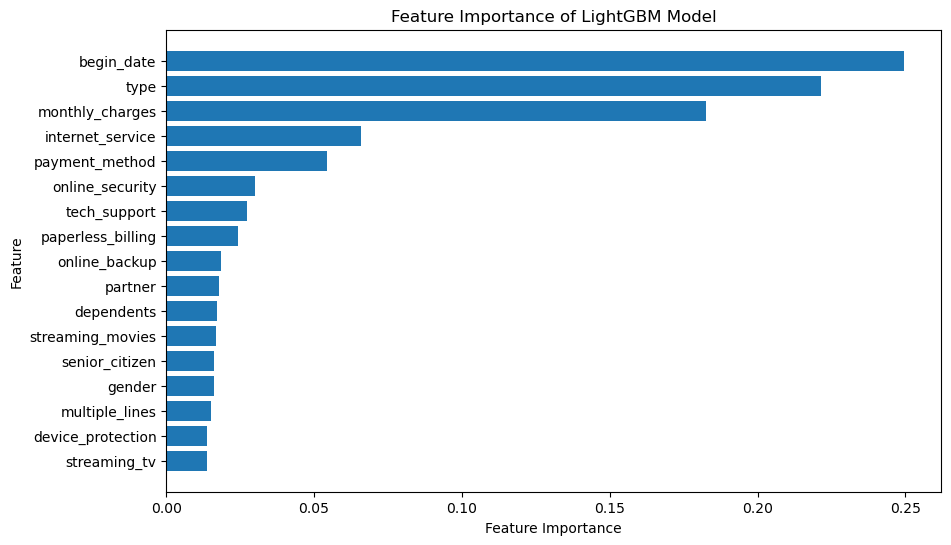

In [63]:
feature_importances = model.feature_importances_
feature_names = label_X_train_val.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance of LightGBM Model')
plt.gca().invert_yaxis()
plt.show()

In this step, I analyzed which features had the most influence on the predictions using the LightGBM model. The bar chart above shows the relative importance of each feature.

Some key takeaways I found:
- **`begin_date`** and **`type`** (contract type) are the top two contributors to the model’s decisions, which makes sense — contract length and how long someone has been with the service are strong churn indicators.
- **`monthly_charges`** also plays a significant role, indicating that customers' monthly expenses can impact churn likelihood.
- Service-related features like **`online_security`**, **`tech_support`**, and **`payment_method`** also contribute meaningfully.
- On the other hand, features like **`streaming_tv`**, **`streaming_movies`**, and **`senior_citizen`** had relatively low importance in this particular model setup.

This insight helps prioritize which features are worth focusing on or potentially engineering further.

# Suggestions: 

Based on the analysis and model insights, here are some actionable suggestions to help reduce churn and improve customer retention:


---
1. Focus on Contract Type and Tenure
---
- Customers on month-to-month contracts are far more likely to churn.
- **Encourage longer-term contracts** by offering discounts or added benefits for annual or bi-annual subscriptions.
- Consider loyalty programs or incentives for customers who’ve stayed past a certain number of months (`begin_date` was a top predictor).
---
2. Monitor High Monthly Charges
---
- Customers with higher `monthly_charges` showed a higher churn rate.
- Offer flexible plans or bundles to better match value with pricing.
- Use predictive models to **proactively offer discounts or alternatives** to customers likely to churn due to cost.
---
3. Promote Internet-Related Add-Ons
---
- Features like `online_security`, `tech_support`, and `device_protection` showed strong relevance.
- Customers who use these services are more likely to stay.
- Consider promoting or bundling these add-ons to improve perceived value.
---
4. Improve Digital Experience
---
- Customers who **don’t use** services like `streaming_tv` or `streaming_movies` were more likely to churn.
- Offer free trials or onboarding tips to boost engagement with these services.
- Collect feedback to improve service usability and content offerings.
---
5. Review Payment Methods
---
- Certain payment types (e.g., manual payments) may be linked with higher churn.
- Encourage automatic billing options and ensure the process is user-friendly and transparent.
---
6. Target Family-Oriented Customers
---
- Features like `partner` and `dependents` also showed some predictive value.
- Family plans or shared accounts might increase retention in this segment.

These suggestions are derived directly from the model's understanding of churn behavior, and can serve as a starting point for strategic retention campaigns or customer experience improvements.
